### $\textbf{1. Motivation}$ 
Inspired by Mandelbrot's The (Mis)Behaviour of Markets, this notebook investigates if financial returns exhibit scaling properties that differ from a simple random walk.

On the one hand, classical financial models often assume that returns are independent and price movements almost random walks. On the other hand, Mandelbrot challenged this, emphasizing the presence of: long-range dependence, scaling behavior, volatility clustering, and heavy tailed distributions.

This notebook focuses on dependence using the **Hurst exponent** calculating the R/S analysis.

The initial experiment compares a simulated Gaussian white noise process with historical SPY daily log-returns.

### $\textbf{2. Hurst exponent}$ 
Its interpretation is:
* $H \approx 0.5$: behavior of a random walk.
* $H > 0.5$: behavior of persistence, when a trend continues in the same direction.
* $H < 0.5$: behavior of anti-persistence, when the market tends to constantly reverse.

These interpretations should be treated carefully, since the estimated Hurst exponent can be affected by finite samples, non-stationarity, volatility clustering and the estimation method itself (as explained in some sections of the book by Mandelbrot, obtaining different exponents forthe same market).

Therefore, in this project the Hurst exponent is treated primarily as a measure of scaling and temporal dependence, rather than as a direct measure of predictability.


### $\textbf{3. R/S Analysis}$ 

The Hurst exponent is estimated using Rescaled Range (R/S) analysis. To perform it, for a window of size \(n\), the time series is divided into blocks. For each block, the cumulative deviations from the block mean are calculated:
$$Y_k = \sum_{t=1}^{k}(X_t-\bar{X})$$

where $\bar{X}$ is the mean of the block.

The range $R(n)$ is then defined as:
$$R(n)=\max(Y_k)-\min(Y_k)$$

The standard deviation of the block is:
$$S(n)=\sqrt{\frac{1}{n}\sum_{t=1}^{n}(X_t-\bar{X})^2}$$

The rescaled range is therefore:
$$\frac{R(n)}{S(n)}$$

For processes exhibiting scaling behavior, the expected relationship can be approximated by:
$$\frac{R(n)}{S(n)} \propto n^H$$

Taking logarithms gives:
$$\log\left(\frac{R(n)}{S(n)}\right)=H\log(n)+C$$


Therefore, $H$ can be estimated as the slope of a least-squares regression between $\log(n)$ and $\log(R/S)$.

The implementation below evaluates multiple logarithmically spaced window sizes and estimates the scaling exponent from the resulting log-log relationship.


### $\textbf{4. Design}$ 

The experiment consists of two complementary tests.

First, a simulated Gaussian white-noise series is used as a baseline. Since the observations are independent, its scaling behavior is expected to be $H \approx 0.5$.

Second, the same estimator is applied to historical SPY data to investigate whether its daily log-returns exhibit different scaling behavior.
- **Asset:** SPY
- **Data frequency:** Daily
- **Sample:** 2023
- **Input:** Log-returns
- **Window sizes:** 20 logarithmically spaced values

[*********************100%***********************]  1 of 1 completed

Hurst (Random Walk): 0.5132  --> Expected ~0.50
Hurst (SPY Log-Returns):     0.6379


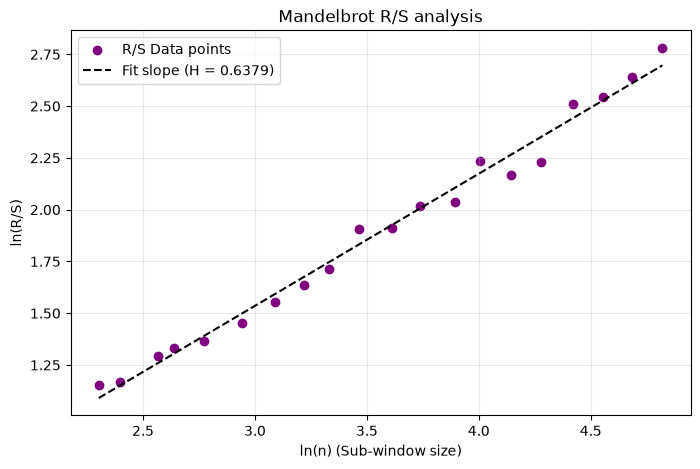

In [10]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

def calculate_hurst(time_series):
    time_series = np.asarray(time_series)
    N = len(time_series)
    
    if N < 20:
        return 0.5  # Return neutral value if window size is too small

    # Sub-window sizes (n) to evaluate
    min_size = 10
    max_size = N // 2
    if max_size <= min_size:
        max_size = N
        
    window_sizes = np.unique(np.logspace(np.log10(min_size), np.log10(max_size), num=20, dtype=int))
    
    rs_values = []
    
    for n in window_sizes:
        if n < 2:
            continue
            
        # Partition the time series into blocks of size n
        num_blocks = N // n
        if num_blocks == 0:
            continue
            
        rs_blocks = []
        for i in range(num_blocks):
            block = time_series[i*n : (i+1)*n]
            
            # Block mean
            mean = np.mean(block)
            
            # Cumulative deviations from the mean
            cum_deviations = np.cumsum(block - mean)
            
            # Range (R) = Max - Min of cumulative deviations
            R = np.max(cum_deviations) - np.min(cum_deviations)
            
            # Standard Deviation (S) of the block
            S = np.std(block)
            
            if S > 1e-10:  # Avoid division by zero
                rs_blocks.append(R / S)
                
        if len(rs_blocks) > 0:
            rs_values.append(np.mean(rs_blocks))
            
    if len(rs_values) < 2:
        return 0.5
        
    # Ordinary Least Squares fit in log-log scale to estimate slope (Hurst exponent)
    log_n = np.log([t for t, rs in zip(window_sizes, rs_values) if rs > 0])
    log_rs = np.log([rs for rs in rs_values if rs > 0])
    
    if len(log_n) < 2:
        return 0.5
        
    hurst = np.polyfit(log_n, log_rs, 1)[0]
    return hurst

# White-noise baseline: independent Gaussian returns.
# For memoryless increments, H is expected to be approximately 0.5.
random_returns = np.random.randn(1000) # Pure memoryless increments
h_random = calculate_hurst(random_returns)

# Empirical test on historical market data
data = yf.download('SPY', start='2023-01-01', end='2024-01-01')['Close']
spy_returns = np.diff(np.log(data.values.flatten()))  # Log-returns
h_spy = calculate_hurst(spy_returns)

print(f"Hurst (Random Walk): {h_random:.4f}  --> Expected ~0.50")
print(f"Hurst (SPY Log-Returns):     {h_spy:.4f}")

# Visual evaluation on SPY returns
series = spy_returns
N = len(series)
window_sizes = np.unique(np.logspace(np.log10(10), np.log10(N // 2), num=20, dtype=int))

log_n, log_rs = [], []
for n in window_sizes:
    num_blocks = N // n
    if num_blocks == 0: 
        continue
    rs_blocks = []
    for i in range(num_blocks):
        block = series[i*n : (i+1)*n]
        mean = np.mean(block)
        cum_dev = np.cumsum(block - mean)
        R = np.max(cum_dev) - np.min(cum_dev)
        S = np.std(block)
        if S > 1e-10: 
            rs_blocks.append(R / S)
    if len(rs_blocks) > 0:
        log_n.append(np.log(n))
        log_rs.append(np.log(np.mean(rs_blocks)))

plt.figure(figsize=(8, 5))
plt.scatter(log_n, log_rs, color='purple', label='R/S Data points')
p = np.polyfit(log_n, log_rs, 1)
plt.plot(log_n, np.polyval(p, log_n), color='black', linestyle='--', label=f'Fit slope (H = {p[0]:.4f})')
plt.title('Mandelbrot R/S analysis')
plt.xlabel('ln(n) (Sub-window size)')
plt.ylabel('ln(R/S)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### $\textbf{5. Results}$ 

The estimated Hurst exponents are:
$$
H_{\text{Gaussian}} = 0.5132
$$

$$
H_{\text{SPY}} = 0.6379
$$

The Gaussian case produces a value close to the theoretical reference of $H=0.5$. The small deviation from 0.5 is expected because the Hurst exponent is estimated from a finite sample. In particular, the simulation contains only 1,000 observations, and the R/S estimator is subject to sampling variability. The result also depends on the selected window sizes and the resulting least-squares fit. Therefore, obtaining exactly $H=0.5$ should not be expected from a finite simulated sample.Therefore, $H=0.5132$ provides a reasonable validation that the implementation behaves consistently with the expected scaling of a memoryless process.

Furthermore, it will not be $H=0.5132$ in every simulation. This is because the Gaussian series is randomly generated each time the code is executed. Therefore, every run produces a different sample of 1,000 observations and consequently a slightly different Hurst estimate.

On the other hand, the estimated Hurst exponent for SPY daily log-returns is higher than the $H=0.5132$ obtained from the Gaussian baseline. In this sample, the result indicates persistent scaling behavior: fluctuations in the return series appear to exhibit a degree of temporal dependence that differs from the memoryless baseline.
 
However, this result should not immediately be interpreted as evidence of exploitable predictability or genuine long-range dependence. Financial return series contain several characteristics that can influence Hurst estimation, including volatility clustering, non-stationarity, heavy tails, and structural changes.

### $\textbf{6. Future work: Time-Varying Hurst Exponent}$  

After evaluating many different periods with the code, it has been empirically demonstrated Hurst exponent is not necessarily constant throughout the history of a financial market. Different market periods may exhibit different statistical properties, meaning that a single Hurst estimate over the entire sample can hide important changes in market behavior.

This motivates the development of a rolling Hurst estimator, where the exponent is recalculated over a moving window throughout the time series.